In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_aws.chat_models import ChatBedrock
import boto3
from typing import TypedDict
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

True

In [3]:
ACCESS_KEY = os.getenv('AWS_ACCESS_KEY')
SECRET_KEY = os.getenv('AWS_SECRET_KEY')
REGION = os.getenv('AWS_REGION')

In [4]:
from botocore.credentials import RefreshableCredentials
from botocore.session import get_session

ROLE_ARN = os.getenv('ROLE_ARN')

ROLE_SESSION_NAME = "bedrock-session"


sts = boto3.client("sts")
 
response = sts.assume_role(
    RoleArn=ROLE_ARN,
    RoleSessionName="bedrock-session"
)
 
creds = response["Credentials"]
 
session = boto3.Session(
    aws_access_key_id=creds["AccessKeyId"],
    aws_secret_access_key=creds["SecretAccessKey"],
    aws_session_token=creds["SessionToken"],
    region_name=REGION
)

bedrock_client = session.client(
    service_name="bedrock-runtime",
    region_name=REGION
)

In [5]:
provider = os.getenv("PROVIDER")
model_id = os.getenv("MODEL_ID")
model_kwargs = {
    "max_tokens":1000,
    "top_p": 0.9,
}

llm = ChatBedrock(
        client=bedrock_client,
        provider=provider,
        model_id=model_id,  
        model_kwargs=model_kwargs,
        streaming=False
    )

In [6]:
class BlogState(TypedDict, total=False):
    title: str
    outline: str
    content: str

In [7]:
def create_outline(state:BlogState)-> BlogState:
    title = state['title']

    prompt = f'Generate a detailed outline for a blog on the title: {title}'
    outline = llm.invoke(prompt).content

    state['outline'] = outline

    return state


In [8]:
def create_blog(state:BlogState)-> BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title: {title} using the following outline \n {outline}'
    content = llm.invoke(prompt).content

    state['content'] = content

    return state


In [9]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [10]:
initial_state = {'title': 'machine learning'}

final_state = workflow.invoke(initial_state)

final_state

{'title': 'machine learning',
 'outline': "# Machine Learning: A Comprehensive Blog Outline\n\n## I. Introduction\n- A. Hook: Real-world ML applications (Netflix, Tesla, healthcare)\n- B. Definition of Machine Learning\n- C. Why ML matters in today's world\n- D. Blog roadmap and what readers will learn\n\n---\n\n## II. Fundamentals of Machine Learning\n- A. What is Machine Learning?\n  - 1. Difference from traditional programming\n  - 2. Core concept: learning from data\n- B. Brief History of Machine Learning\n  - 1. Key milestones and breakthroughs\n  - 2. Evolution of the field\n- C. Why Machine Learning is Important\n  - 1. Business applications\n  - 2. Scientific advancement\n  - 3. Solving complex problems\n\n---\n\n## III. Three Main Types of Machine Learning\n- A. Supervised Learning\n  - 1. Definition and how it works\n  - 2. Common algorithms (Linear Regression, Decision Trees, SVM)\n  - 3. Use cases and examples\n- B. Unsupervised Learning\n  - 1. Definition and characteristi

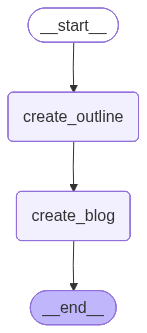

In [11]:
workflow

In [12]:
print(final_state['outline'])

# Machine Learning: A Comprehensive Blog Outline

## I. Introduction
- A. Hook: Real-world ML applications (Netflix, Tesla, healthcare)
- B. Definition of Machine Learning
- C. Why ML matters in today's world
- D. Blog roadmap and what readers will learn

---

## II. Fundamentals of Machine Learning
- A. What is Machine Learning?
  - 1. Difference from traditional programming
  - 2. Core concept: learning from data
- B. Brief History of Machine Learning
  - 1. Key milestones and breakthroughs
  - 2. Evolution of the field
- C. Why Machine Learning is Important
  - 1. Business applications
  - 2. Scientific advancement
  - 3. Solving complex problems

---

## III. Three Main Types of Machine Learning
- A. Supervised Learning
  - 1. Definition and how it works
  - 2. Common algorithms (Linear Regression, Decision Trees, SVM)
  - 3. Use cases and examples
- B. Unsupervised Learning
  - 1. Definition and characteristics
  - 2. Common algorithms (K-Means, Hierarchical Clustering, PCA)
  - 3

In [13]:
print(final_state['content'])

# Machine Learning: A Comprehensive Guide to the Future of Intelligent Systems

## I. Introduction

Imagine a world where your streaming service knows exactly what you want to watch before you finish scrolling, where self-driving cars navigate complex traffic patterns autonomously, and where doctors can detect diseases years before symptoms appear. This isn't science fiction—it's the reality of machine learning today.

**Netflix** recommends your next binge-worthy series with uncanny accuracy. **Tesla's** vehicles learn to drive safer with each mile traveled. **Healthcare providers** use AI to diagnose cancers more accurately than human radiologists. These aren't isolated examples; they represent the transformative power of machine learning reshaping virtually every industry.

### What is Machine Learning?

Machine Learning (ML) is a subset of artificial intelligence that enables computers to learn from data and improve their performance without being explicitly programmed for every sc